# Lab 3: Contextual Bandit-Based News Article Recommendation System
## Part 1: Data Preprocessing and User Classification

**Student Roll Number:** U20230090  
**Name:** Lakshit Tyagi

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Pre-processing (10 Points)

### 1.1 Load Datasets

DATASET OVERVIEW
Train (with labels): (2000, 33)
Test (unlabeled): (2000, 32)
News Articles: (209527, 6)

Target column: 'label'
Distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


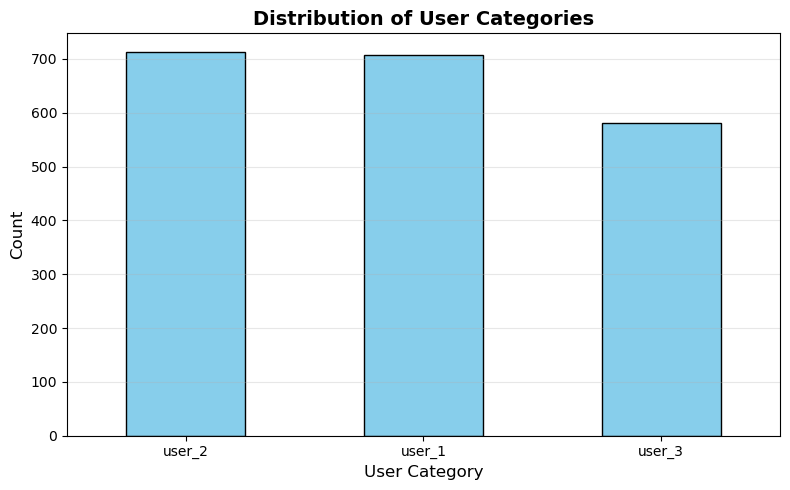

In [3]:
# Load datasets
train_users_full = pd.read_csv('data/train_users.csv')
test_users_final = pd.read_csv('data/test_users.csv')  # For final predictions (unlabeled)
news_articles = pd.read_csv('data/news_articles.csv')

# Clean column names
train_users_full.columns = train_users_full.columns.str.strip()
test_users_final.columns = test_users_final.columns.str.strip()
news_articles.columns = news_articles.columns.str.strip()

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Train (with labels): {train_users_full.shape}")
print(f"Test (unlabeled): {test_users_final.shape}")
print(f"News Articles: {news_articles.shape}")

print(f"\nTarget column: 'label'")
print(f"Distribution:\n{train_users_full['label'].value_counts()}")

# Visualize
plt.figure(figsize=(8, 5))
train_users_full['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of User Categories', fontsize=14, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Split into Train/Validation

In [4]:
# Separate features and target
TARGET_COLUMN = 'label'

X_full = train_users_full.drop([TARGET_COLUMN, 'user_id'], axis=1)
y_full = train_users_full[TARGET_COLUMN]

# Split into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full  # Ensures balanced split
)

print("="*60)
print("TRAIN-VALIDATION SPLIT (80-20)")
print("="*60)
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")

print(f"\nTraining set distribution:\n{y_train.value_counts()}")
print(f"\nValidation set distribution:\n{y_val.value_counts()}")

print(f"\nFeatures ({len(X_train.columns)}):")
print(X_train.columns.tolist())

TRAIN-VALIDATION SPLIT (80-20)
Training set: X=(1600, 31), y=(1600,)
Validation set: X=(400, 31), y=(400,)

Training set distribution:
label
user_2    570
user_1    565
user_3    465
Name: count, dtype: int64

Validation set distribution:
label
user_2    142
user_1    142
user_3    116
Name: count, dtype: int64

Features (31):
['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'browser_version', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']


### 1.3 Handle Missing Values

In [5]:
# Identify column types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical/Boolean columns: {len(categorical_cols)}")
if len(categorical_cols) > 0:
    print(f"Categorical columns: {list(categorical_cols)}")

print(f"\nMissing values before:")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_val: {X_val.isnull().sum().sum()}")

# Fill numerical with median
for col in numerical_cols:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_val[col].fillna(median_val, inplace=True)

# Fill categorical with mode
for col in categorical_cols:
    if X_train[col].isnull().sum() > 0:
        mode_val = X_train[col].mode()[0]
        X_train[col].fillna(mode_val, inplace=True)
        X_val[col].fillna(mode_val, inplace=True)

print(f"\nMissing values after:")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_val: {X_val.isnull().sum().sum()}")
print("✓ Missing values handled")

HANDLING MISSING VALUES
Numerical columns: 28
Categorical/Boolean columns: 3
Categorical columns: ['browser_version', 'region_code', 'subscriber']

Missing values before:
X_train: 565
X_val: 133

Missing values after:
X_train: 0
X_val: 0
✓ Missing values handled


### 1.4 Categorical Feature Encoding

In [6]:
# Convert boolean to int
if 'subscriber' in X_train.columns:
    X_train['subscriber'] = X_train['subscriber'].astype(int)
    X_val['subscriber'] = X_val['subscriber'].astype(int)
    print("✓ Converted 'subscriber' from boolean to int (0/1)")

# Encode other categorical features
label_encoders = {}
categorical_cols = X_train.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print(f"\nEncoding {len(categorical_cols)} categorical columns: {list(categorical_cols)}")
    
    for col in categorical_cols:
        le = LabelEncoder()
        
        # Fit on train
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        label_encoders[col] = le
        
        # Transform validation
        X_val[col] = X_val[col].astype(str)
        X_val[col] = X_val[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        X_val[col] = le.transform(X_val[col])
    
    print("✓ Categorical encoding complete")
else:
    print("\nNo categorical columns to encode")

print(f"\nAll features are now numerical")

✓ Converted 'subscriber' from boolean to int (0/1)

Encoding 2 categorical columns: ['browser_version', 'region_code']
✓ Categorical encoding complete

All features are now numerical


### 1.5 Feature Scaling

In [7]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("="*60)
print("FEATURE SCALING COMPLETE")
print("="*60)
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print("\n✓ Ready for training!")

FEATURE SCALING COMPLETE
X_train_scaled: (1600, 31)
X_val_scaled: (400, 31)

✓ Ready for training!


## 2. User Classification (10 Points)

### 2.1 Train and Evaluate Classifiers


TRAINING: Decision Tree

Validation Accuracy: 0.5875

Classification Report:
              precision    recall  f1-score   support

      user_1       0.27      0.06      0.10       142
      user_2       0.52      0.98      0.68       142
      user_3       0.87      0.75      0.81       116

    accuracy                           0.59       400
   macro avg       0.55      0.60      0.53       400
weighted avg       0.53      0.59      0.51       400



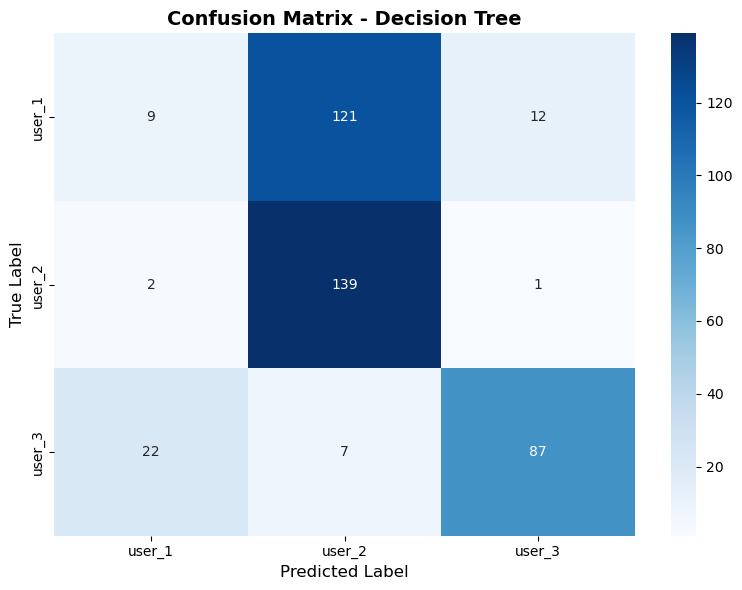


TRAINING: Logistic Regression

Validation Accuracy: 0.8625

Classification Report:
              precision    recall  f1-score   support

      user_1       0.87      0.80      0.83       142
      user_2       0.84      0.92      0.88       142
      user_3       0.89      0.87      0.88       116

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



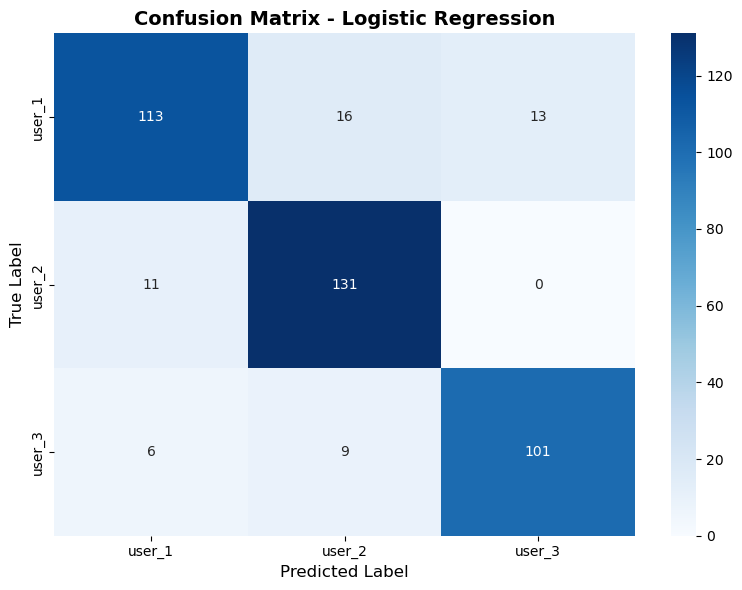


TRAINING: Random Forest

Validation Accuracy: 0.9075

Classification Report:
              precision    recall  f1-score   support

      user_1       0.88      0.89      0.88       142
      user_2       0.97      0.89      0.93       142
      user_3       0.88      0.96      0.92       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



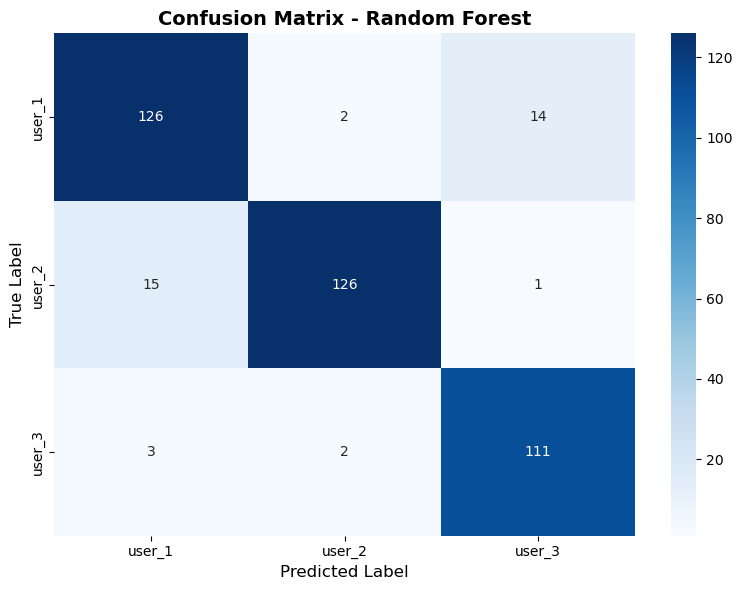

In [8]:
# Initialize classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, solver='saga'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15)
}

results = {}
unique_labels = sorted(y_train.unique())

for name, clf in classifiers.items():
    print(f"\n{'='*60}")
    print(f"TRAINING: {name}")
    print(f"{'='*60}")
    
    # Train
    clf.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_pred = clf.predict(X_val_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_val, y_pred)
    results[name] = accuracy
    
    print(f"\nValidation Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_labels,
                yticklabels=unique_labels)
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

### 2.2 Model Comparison


MODEL COMPARISON
Decision Tree: 0.5875
Logistic Regression: 0.8625
Random Forest: 0.9075


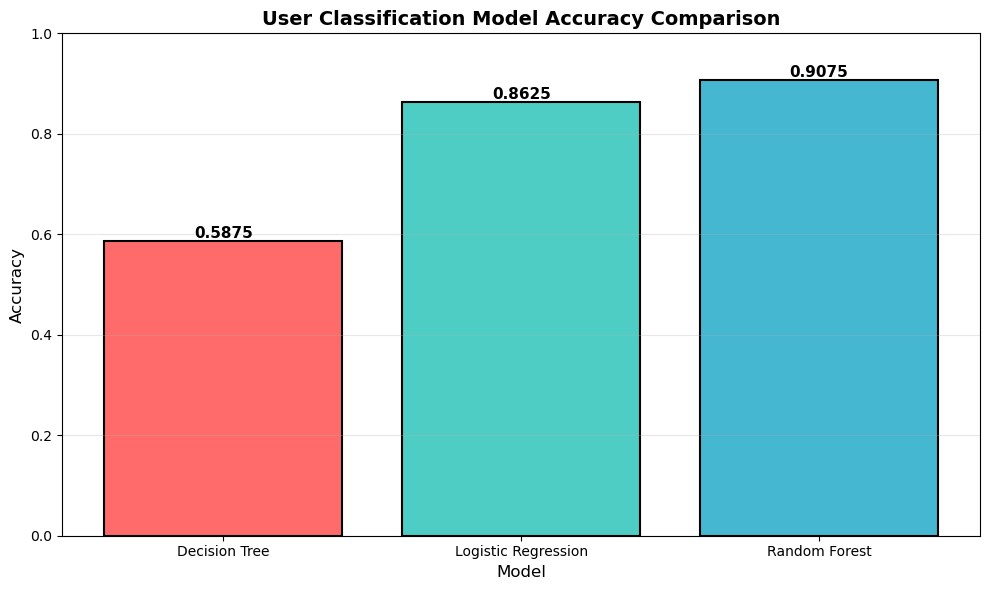


🏆 Best Model: Random Forest
   Validation Accuracy: 0.9075


In [9]:
# Compare models
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.title('User Classification Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
best_model = classifiers[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Validation Accuracy: {results[best_model_name]:.4f}")

### 2.3 Save the Best Model (Optional)

In [10]:
import pickle

# Save the best model and preprocessing objects
with open('user_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nModel and preprocessing objects saved successfully!")


Model and preprocessing objects saved successfully!


### Results

- Best Model: [Random Forest]
- Test Accuracy: [0.9075]

This classifier will serve as the **Context Detector** for the contextual bandit system in the next phase of the assignment.

## Part 2: Contextual Bandit Algorithms & Recommendation System

## 3. Contextual Bandit Algorithms (45 Points)

NEWS ARTICLES DATASET
Shape: (209527, 6)

Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

First 5 rows:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to p

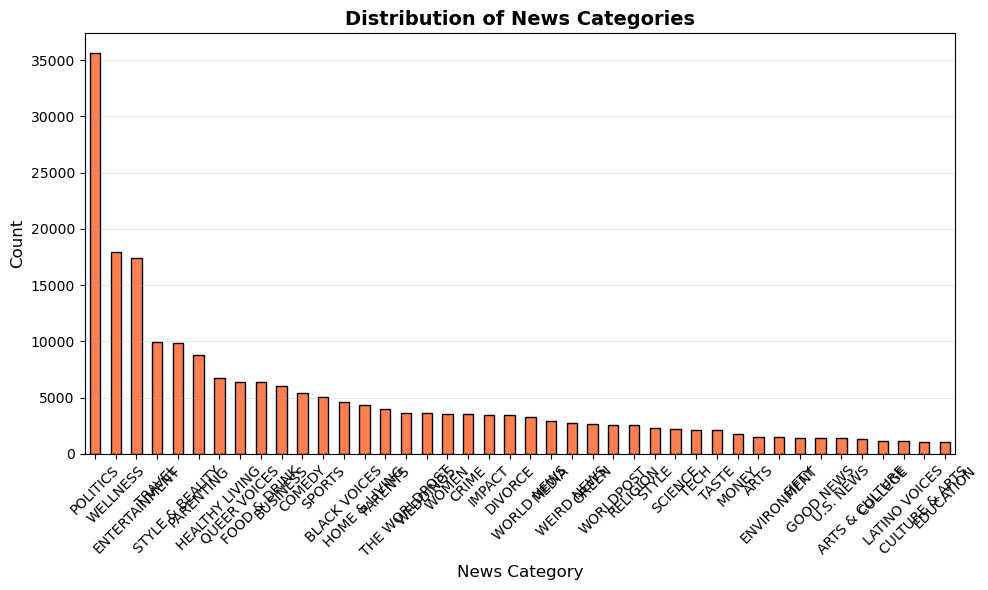

In [11]:
# ============================================================
# PART 2: NEWS ARTICLES EXPLORATION
# ============================================================

print("="*60)
print("NEWS ARTICLES DATASET")
print("="*60)
print(f"Shape: {news_articles.shape}")
print(f"\nColumns: {news_articles.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(news_articles.head())

# Check for 'category' column
if 'category' in news_articles.columns:
    print(f"\n✓ 'category' column found")
    print(f"News categories: {news_articles['category'].unique()}")
    print(f"\nCategory distribution:")
    print(news_articles['category'].value_counts())
    
    # Visualize
    plt.figure(figsize=(10, 6))
    news_articles['category'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Distribution of News Categories', fontsize=14, fontweight='bold')
    plt.xlabel('News Category', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'category' column not found!")

In [12]:
# ============================================================
# PART 3: ARM INDEX MAPPING
# ============================================================

# Define the mapping between (user_category, news_category) -> arm_index
# Based on Table 1 in assignment

def get_arm_index(user_category, news_category):
    """
    Map (user_category, news_category) to arm index j for sampler
    
    Args:
        user_category: 'user_1', 'user_2', or 'user_3'
        news_category: 'Entertainment', 'Education', 'Tech', or 'Crime'
    
    Returns:
        arm_index: j value (0-11)
    """
    user_map = {'user_1': 0, 'user_2': 4, 'user_3': 8}
    news_map = {'Entertainment': 0, 'Education': 1, 'Tech': 2, 'Crime': 3}
    
    # Normalize category names (handle case sensitivity)
    news_category_normalized = news_category.lower().capitalize()
    
    return user_map[user_category] + news_map[news_category_normalized]

def get_context_arms(user_category):
    """Get all arm indices for a specific user context"""
    categories = ['Entertainment', 'Education', 'Tech', 'Crime']
    return [get_arm_index(user_category, cat) for cat in categories]

# Test the mapping
print("="*60)
print("ARM INDEX MAPPING")
print("="*60)
print("\nArm index mapping:")
for user in ['user_1', 'user_2', 'user_3']:
    print(f"\n{user}:")
    for news in ['Entertainment', 'Education', 'Tech', 'Crime']:
        arm = get_arm_index(user, news)
        print(f"  {news:15s} -> arm {arm}")

# Verify we have all 12 arms
all_arms = []
for user in ['user_1', 'user_2', 'user_3']:
    all_arms.extend(get_context_arms(user))
print(f"\n✓ Total unique arms: {len(all_arms)} (should be 12)")

ARM INDEX MAPPING

Arm index mapping:

user_1:
  Entertainment   -> arm 0
  Education       -> arm 1
  Tech            -> arm 2
  Crime           -> arm 3

user_2:
  Entertainment   -> arm 4
  Education       -> arm 5
  Tech            -> arm 6
  Crime           -> arm 7

user_3:
  Entertainment   -> arm 8
  Education       -> arm 9
  Tech            -> arm 10
  Crime           -> arm 11

✓ Total unique arms: 12 (should be 12)


In [13]:
# ============================================================
# PART 4: REWARD SAMPLER INITIALIZATION
# ============================================================

from rlcmab_sampler import sampler

# Initialize with your roll number
ROLL_NUMBER = 90
reward_sampler = sampler(ROLL_NUMBER)

print("="*60)
print("REWARD SAMPLER INITIALIZED")
print("="*60)
print(f"Roll Number: {ROLL_NUMBER}")

# Test sampling from each arm
print("\nTesting reward sampling from all 12 arms:")
test_samples = {}
for j in range(12):
    reward = reward_sampler.sample(j)
    test_samples[j] = reward
    print(f"Arm {j:2d}: reward = {reward:.4f}")

print("\n✓ Sampler working correctly!")

REWARD SAMPLER INITIALIZED
Roll Number: 90

Testing reward sampling from all 12 arms:
Arm  0: reward = 8.2849
Arm  1: reward = -4.5682
Arm  2: reward = 2.7039
Arm  3: reward = -4.2963
Arm  4: reward = 3.1367
Arm  5: reward = 4.1595
Arm  6: reward = 0.2978
Arm  7: reward = -6.9010
Arm  8: reward = -1.1080
Arm  9: reward = -5.6690
Arm 10: reward = 4.4218
Arm 11: reward = -0.5173

✓ Sampler working correctly!


### 3.1 Epsilon-Greedy (15 Points)

In [23]:
# ============================================================
# PART 5: EPSILON-GREEDY ALGORITHM
# ============================================================

import numpy as np
from collections import defaultdict

class EpsilonGreedy:
    """Epsilon-Greedy algorithm for contextual bandits"""
    
    def __init__(self, epsilon, num_arms, sampler):
        self.epsilon = epsilon
        self.num_arms = num_arms
        self.sampler = sampler
        
        # Track statistics per arm
        self.arm_counts = defaultdict(int)
        self.arm_rewards = defaultdict(float)
        self.arm_avg_rewards = defaultdict(float)
        
        # History tracking
        self.reward_history = []
        self.arm_history = []
        self.cumulative_rewards = []
        
    def select_arm(self, context_arms):
        """Select an arm using epsilon-greedy strategy"""
        # Exploration: random arm
        if np.random.random() < self.epsilon:
            return np.random.choice(context_arms)
        
        # Exploitation: best arm so far
        context_arm_values = {arm: self.arm_avg_rewards.get(arm, 0) for arm in context_arms}
        
        if all(v == 0 for v in context_arm_values.values()):
            return np.random.choice(context_arms)
        
        return max(context_arm_values, key=context_arm_values.get)
    
    def update(self, arm, reward):
        """Update statistics after pulling an arm"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.arm_avg_rewards[arm] = self.arm_rewards[arm] / self.arm_counts[arm]
        
        self.reward_history.append(reward)
        self.arm_history.append(arm)
        
        # Track cumulative reward
        if len(self.cumulative_rewards) == 0:
            self.cumulative_rewards.append(reward)
        else:
            self.cumulative_rewards.append(self.cumulative_rewards[-1] + reward)
    
    def run_simulation(self, T, user_categories):
        """Run simulation for T timesteps"""
        print(f"\nRunning Epsilon-Greedy (ε={self.epsilon}) for {T} steps...")
        
        for t in range(T):
            # Randomly sample a user context
            user = np.random.choice(user_categories)
            context_arms = get_context_arms(user)
            
            # Select and pull arm
            arm = self.select_arm(context_arms)
            reward = self.sampler.sample(arm)
            
            # Update statistics
            self.update(arm, reward)
            
            if (t + 1) % 2000 == 0:
                avg_reward = np.mean(self.reward_history[-2000:])
                print(f"  Step {t+1}/{T}: Avg reward (last 2000) = {avg_reward:.4f}")
        
        total_reward = sum(self.reward_history)
        avg_reward = total_reward / T
        
        print(f"\n✓ Simulation complete!")
        print(f"  Total reward: {total_reward:.2f}")
        print(f"  Average reward: {avg_reward:.4f}")
        
        return total_reward
    
    def get_expected_rewards(self):
        """Get expected reward for each arm"""
        return dict(self.arm_avg_rewards)

print("="*60)
print("EPSILON-GREEDY IMPLEMENTATION")
print("="*60)

# Define user categories
user_categories = ['user_1', 'user_2', 'user_3']
T = 10000

# Run with multiple epsilon values for hyperparameter tuning
epsilon_values = [0.01, 0.1, 0.3]
eg_agents = {}

for eps in epsilon_values:
    print(f"\n{'='*60}")
    print(f"Training Epsilon-Greedy with ε = {eps}")
    print(f"{'='*60}")
    
    agent = EpsilonGreedy(epsilon=eps, num_arms=12, sampler=reward_sampler)
    agent.run_simulation(T, user_categories)
    eg_agents[eps] = agent
    
    # Show learned arm values
    print(f"\nLearned average rewards per arm:")
    expected_rewards = agent.get_expected_rewards()
    for arm in sorted(expected_rewards.keys()):
        print(f"  Arm {arm:2d}: {expected_rewards[arm]:.4f} (pulled {agent.arm_counts[arm]} times)")

print(f"\n{'='*60}")
print("EPSILON-GREEDY: Summary")
print(f"{'='*60}")
for eps, agent in eg_agents.items():
    avg_reward = np.mean(agent.reward_history)
    print(f"ε = {eps:4.2f}: Average Reward = {avg_reward:.4f}")

EPSILON-GREEDY IMPLEMENTATION

Training Epsilon-Greedy with ε = 0.01

Running Epsilon-Greedy (ε=0.01) for 10000 steps...
  Step 2000/10000: Avg reward (last 2000) = 5.6401
  Step 4000/10000: Avg reward (last 2000) = 5.5848
  Step 6000/10000: Avg reward (last 2000) = 5.6043
  Step 8000/10000: Avg reward (last 2000) = 5.6205
  Step 10000/10000: Avg reward (last 2000) = 5.6025

✓ Simulation complete!
  Total reward: 56104.58
  Average reward: 5.6105

Learned average rewards per arm:
  Arm  0: 7.6948 (pulled 3291 times)
  Arm  1: -4.0745 (pulled 10 times)
  Arm  2: 1.8438 (pulled 10 times)
  Arm  3: -5.7102 (pulled 8 times)
  Arm  4: 3.5404 (pulled 12 times)
  Arm  5: 4.4664 (pulled 3325 times)
  Arm  6: -0.4076 (pulled 5 times)
  Arm  7: -7.3607 (pulled 8 times)
  Arm  8: -0.4807 (pulled 9 times)
  Arm  9: -6.5929 (pulled 8 times)
  Arm 10: 4.8602 (pulled 3308 times)
  Arm 11: -0.6766 (pulled 6 times)

Training Epsilon-Greedy with ε = 0.1

Running Epsilon-Greedy (ε=0.1) for 10000 steps...

### 3.2 Upper Confidence Bound (UCB) (15 Points)

In [15]:
# ============================================================
# PART 6: UCB (UPPER CONFIDENCE BOUND) ALGORITHM
# ============================================================

class UCB:
    """UCB algorithm for contextual bandits"""
    
    def __init__(self, c, num_arms, sampler):
        self.c = c  # Exploration parameter
        self.num_arms = num_arms
        self.sampler = sampler
        
        # Track statistics per arm
        self.arm_counts = defaultdict(int)
        self.arm_rewards = defaultdict(float)
        self.arm_avg_rewards = defaultdict(float)
        
        # History tracking
        self.reward_history = []
        self.arm_history = []
        self.cumulative_rewards = []
        self.total_counts = 0
        
    def calculate_ucb(self, arm):
        """Calculate UCB value for an arm"""
        if self.arm_counts[arm] == 0:
            return float('inf')  # Ensure unvisited arms are tried first
        
        avg_reward = self.arm_avg_rewards[arm]
        exploration_bonus = self.c * np.sqrt(np.log(self.total_counts + 1) / self.arm_counts[arm])
        
        return avg_reward + exploration_bonus
    
    def select_arm(self, context_arms):
        """Select an arm using UCB strategy"""
        # Calculate UCB for each arm in context
        ucb_values = {arm: self.calculate_ucb(arm) for arm in context_arms}
        
        # Select arm with highest UCB
        return max(ucb_values, key=ucb_values.get)
    
    def update(self, arm, reward):
        """Update statistics after pulling an arm"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.arm_avg_rewards[arm] = self.arm_rewards[arm] / self.arm_counts[arm]
        self.total_counts += 1
        
        self.reward_history.append(reward)
        self.arm_history.append(arm)
        
        # Track cumulative reward
        if len(self.cumulative_rewards) == 0:
            self.cumulative_rewards.append(reward)
        else:
            self.cumulative_rewards.append(self.cumulative_rewards[-1] + reward)
    
    def run_simulation(self, T, user_categories):
        """Run simulation for T timesteps"""
        print(f"\nRunning UCB (c={self.c}) for {T} steps...")
        
        for t in range(T):
            # Randomly sample a user context
            user = np.random.choice(user_categories)
            context_arms = get_context_arms(user)
            
            # Select and pull arm
            arm = self.select_arm(context_arms)
            reward = self.sampler.sample(arm)
            
            # Update statistics
            self.update(arm, reward)
            
            if (t + 1) % 2000 == 0:
                avg_reward = np.mean(self.reward_history[-2000:])
                print(f"  Step {t+1}/{T}: Avg reward (last 2000) = {avg_reward:.4f}")
        
        total_reward = sum(self.reward_history)
        avg_reward = total_reward / T
        
        print(f"\n✓ Simulation complete!")
        print(f"  Total reward: {total_reward:.2f}")
        print(f"  Average reward: {avg_reward:.4f}")
        
        return total_reward
    
    def get_expected_rewards(self):
        """Get expected reward for each arm"""
        return dict(self.arm_avg_rewards)

print("="*60)
print("UCB IMPLEMENTATION")
print("="*60)

# Run with multiple c values for hyperparameter tuning
c_values = [0.5, 1.0, 2.0]
ucb_agents = {}

for c in c_values:
    print(f"\n{'='*60}")
    print(f"Training UCB with c = {c}")
    print(f"{'='*60}")
    
    agent = UCB(c=c, num_arms=12, sampler=reward_sampler)
    agent.run_simulation(T, user_categories)
    ucb_agents[c] = agent
    
    # Show learned arm values
    print(f"\nLearned average rewards per arm:")
    expected_rewards = agent.get_expected_rewards()
    for arm in sorted(expected_rewards.keys()):
        print(f"  Arm {arm:2d}: {expected_rewards[arm]:.4f} (pulled {agent.arm_counts[arm]} times)")

print(f"\n{'='*60}")
print("UCB: Summary")
print(f"{'='*60}")
for c, agent in ucb_agents.items():
    avg_reward = np.mean(agent.reward_history)
    print(f"c = {c:4.1f}: Average Reward = {avg_reward:.4f}")

UCB IMPLEMENTATION

Training UCB with c = 0.5

Running UCB (c=0.5) for 10000 steps...
  Step 2000/10000: Avg reward (last 2000) = 5.6591
  Step 4000/10000: Avg reward (last 2000) = 5.6927
  Step 6000/10000: Avg reward (last 2000) = 5.6503
  Step 8000/10000: Avg reward (last 2000) = 5.7256
  Step 10000/10000: Avg reward (last 2000) = 5.6164

✓ Simulation complete!
  Total reward: 56688.27
  Average reward: 5.6688

Learned average rewards per arm:
  Arm  0: 7.7149 (pulled 3327 times)
  Arm  1: -4.8194 (pulled 1 times)
  Arm  2: 4.2139 (pulled 1 times)
  Arm  3: -4.3605 (pulled 1 times)
  Arm  4: 3.0200 (pulled 2 times)
  Arm  5: 4.4720 (pulled 3385 times)
  Arm  6: -1.8075 (pulled 1 times)
  Arm  7: -8.2816 (pulled 1 times)
  Arm  8: -1.7189 (pulled 1 times)
  Arm  9: -6.2740 (pulled 1 times)
  Arm 10: 4.8505 (pulled 3278 times)
  Arm 11: -0.0688 (pulled 1 times)

Training UCB with c = 1.0

Running UCB (c=1.0) for 10000 steps...
  Step 2000/10000: Avg reward (last 2000) = 5.6363
  Step 4

### 3.3 SoftMax (15 Points)

In [16]:
# ============================================================
# PART 7: SOFTMAX ALGORITHM
# ============================================================

class SoftMax:
    """SoftMax algorithm for contextual bandits"""
    
    def __init__(self, tau, num_arms, sampler):
        self.tau = tau  # Temperature parameter
        self.num_arms = num_arms
        self.sampler = sampler
        
        # Track statistics per arm
        self.arm_counts = defaultdict(int)
        self.arm_rewards = defaultdict(float)
        self.arm_avg_rewards = defaultdict(float)
        
        # History tracking
        self.reward_history = []
        self.arm_history = []
        self.cumulative_rewards = []
        
    def calculate_probabilities(self, context_arms):
        """Calculate SoftMax probabilities for arms"""
        # Get average rewards for context arms
        rewards = np.array([self.arm_avg_rewards.get(arm, 0) for arm in context_arms])
        
        # SoftMax formula
        exp_values = np.exp(rewards / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        return probabilities
    
    def select_arm(self, context_arms):
        """Select an arm using SoftMax strategy"""
        probabilities = self.calculate_probabilities(context_arms)
        
        # Sample arm based on probabilities
        selected_arm = np.random.choice(context_arms, p=probabilities)
        
        return selected_arm
    
    def update(self, arm, reward):
        """Update statistics after pulling an arm"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.arm_avg_rewards[arm] = self.arm_rewards[arm] / self.arm_counts[arm]
        
        self.reward_history.append(reward)
        self.arm_history.append(arm)
        
        # Track cumulative reward
        if len(self.cumulative_rewards) == 0:
            self.cumulative_rewards.append(reward)
        else:
            self.cumulative_rewards.append(self.cumulative_rewards[-1] + reward)
    
    def run_simulation(self, T, user_categories):
        """Run simulation for T timesteps"""
        print(f"\nRunning SoftMax (τ={self.tau}) for {T} steps...")
        
        for t in range(T):
            # Randomly sample a user context
            user = np.random.choice(user_categories)
            context_arms = get_context_arms(user)
            
            # Select and pull arm
            arm = self.select_arm(context_arms)
            reward = self.sampler.sample(arm)
            
            # Update statistics
            self.update(arm, reward)
            
            if (t + 1) % 2000 == 0:
                avg_reward = np.mean(self.reward_history[-2000:])
                print(f"  Step {t+1}/{T}: Avg reward (last 2000) = {avg_reward:.4f}")
        
        total_reward = sum(self.reward_history)
        avg_reward = total_reward / T
        
        print(f"\n✓ Simulation complete!")
        print(f"  Total reward: {total_reward:.2f}")
        print(f"  Average reward: {avg_reward:.4f}")
        
        return total_reward
    
    def get_expected_rewards(self):
        """Get expected reward for each arm"""
        return dict(self.arm_avg_rewards)

print("="*60)
print("SOFTMAX IMPLEMENTATION")
print("="*60)

# Run with tau = 1 as specified in assignment
tau = 1.0

print(f"\n{'='*60}")
print(f"Training SoftMax with τ = {tau}")
print(f"{'='*60}")

softmax_agent = SoftMax(tau=tau, num_arms=12, sampler=reward_sampler)
softmax_agent.run_simulation(T, user_categories)

# Show learned arm values
print(f"\nLearned average rewards per arm:")
expected_rewards = softmax_agent.get_expected_rewards()
for arm in sorted(expected_rewards.keys()):
    print(f"  Arm {arm:2d}: {expected_rewards[arm]:.4f} (pulled {softmax_agent.arm_counts[arm]} times)")

avg_reward = np.mean(softmax_agent.reward_history)
print(f"\nSoftMax (τ={tau}): Average Reward = {avg_reward:.4f}")

SOFTMAX IMPLEMENTATION

Training SoftMax with τ = 1.0

Running SoftMax (τ=1.0) for 10000 steps...
  Step 2000/10000: Avg reward (last 2000) = 5.5297
  Step 4000/10000: Avg reward (last 2000) = 5.5404
  Step 6000/10000: Avg reward (last 2000) = 5.4904
  Step 8000/10000: Avg reward (last 2000) = 5.5290
  Step 10000/10000: Avg reward (last 2000) = 5.5348

✓ Simulation complete!
  Total reward: 55248.68
  Average reward: 5.5249

Learned average rewards per arm:
  Arm  0: 7.6910 (pulled 3256 times)
  Arm  1: -3.6576 (pulled 1 times)
  Arm  4: 3.3924 (pulled 805 times)
  Arm  5: 4.5008 (pulled 2527 times)
  Arm  6: -1.0265 (pulled 21 times)
  Arm  7: -7.7816 (pulled 1 times)
  Arm  8: -0.7569 (pulled 8 times)
  Arm  9: -7.4002 (pulled 1 times)
  Arm 10: 4.8223 (pulled 3348 times)
  Arm 11: 0.1271 (pulled 32 times)

SoftMax (τ=1.0): Average Reward = 5.5249


PLOTS: AVERAGE REWARD VS TIME

1. Epsilon-Greedy


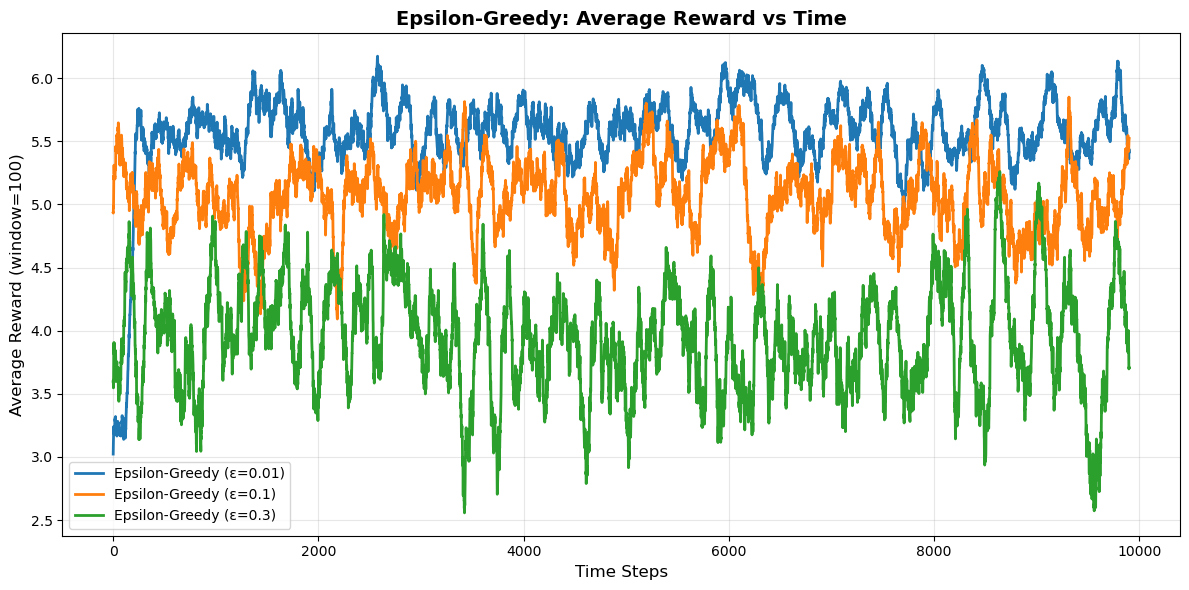


2. UCB


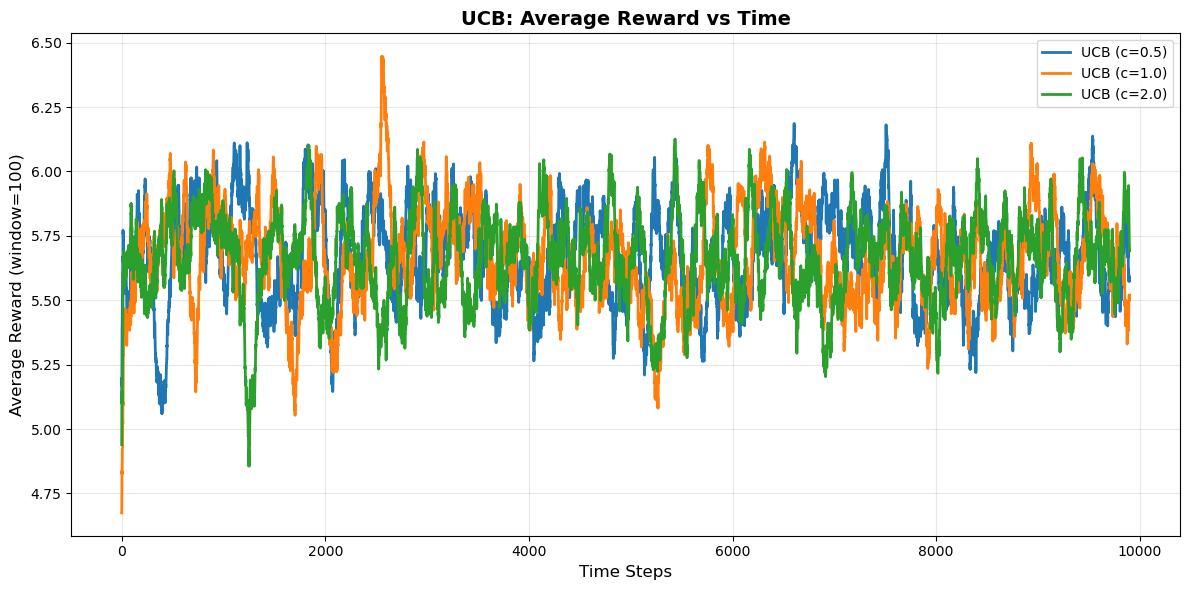


3. SoftMax


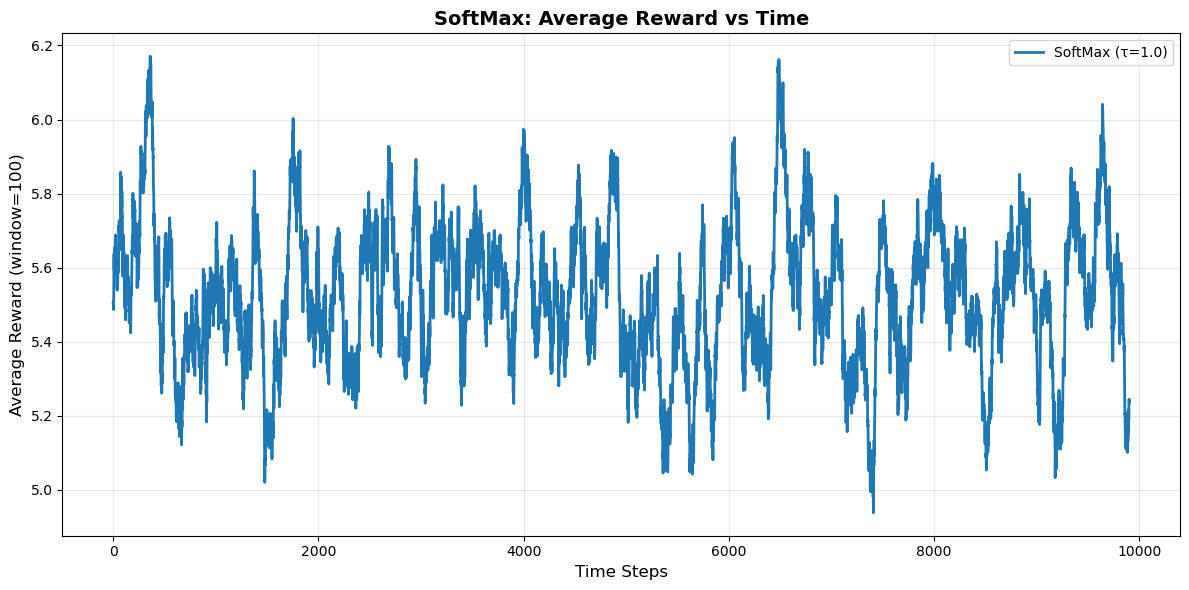

In [17]:
# ============================================================
# PART 8: VISUALIZATION - AVERAGE REWARD VS TIME
# ============================================================

def plot_average_reward_vs_time(agents_dict, algorithm_name, window_size=100):
    """
    Plot average reward over time for different hyperparameters
    
    Args:
        agents_dict: Dictionary of {param_value: agent}
        algorithm_name: Name of the algorithm
        window_size: Window for moving average
    """
    plt.figure(figsize=(12, 6))
    
    for param, agent in agents_dict.items():
        # Calculate moving average
        rewards = agent.reward_history
        moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        
        # Plot
        plt.plot(range(len(moving_avg)), moving_avg, label=f'{algorithm_name} ({param})', linewidth=2)
    
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Average Reward (window={window_size})', fontsize=12)
    plt.title(f'{algorithm_name}: Average Reward vs Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for Epsilon-Greedy
print("="*60)
print("PLOTS: AVERAGE REWARD VS TIME")
print("="*60)

print("\n1. Epsilon-Greedy")
eg_dict = {f'ε={eps}': agent for eps, agent in eg_agents.items()}
plot_average_reward_vs_time(eg_dict, 'Epsilon-Greedy', window_size=100)

print("\n2. UCB")
ucb_dict = {f'c={c}': agent for c, agent in ucb_agents.items()}
plot_average_reward_vs_time(ucb_dict, 'UCB', window_size=100)

print("\n3. SoftMax")
softmax_dict = {f'τ={tau}': softmax_agent}
plot_average_reward_vs_time(softmax_dict, 'SoftMax', window_size=100)

HYPERPARAMETER COMPARISON


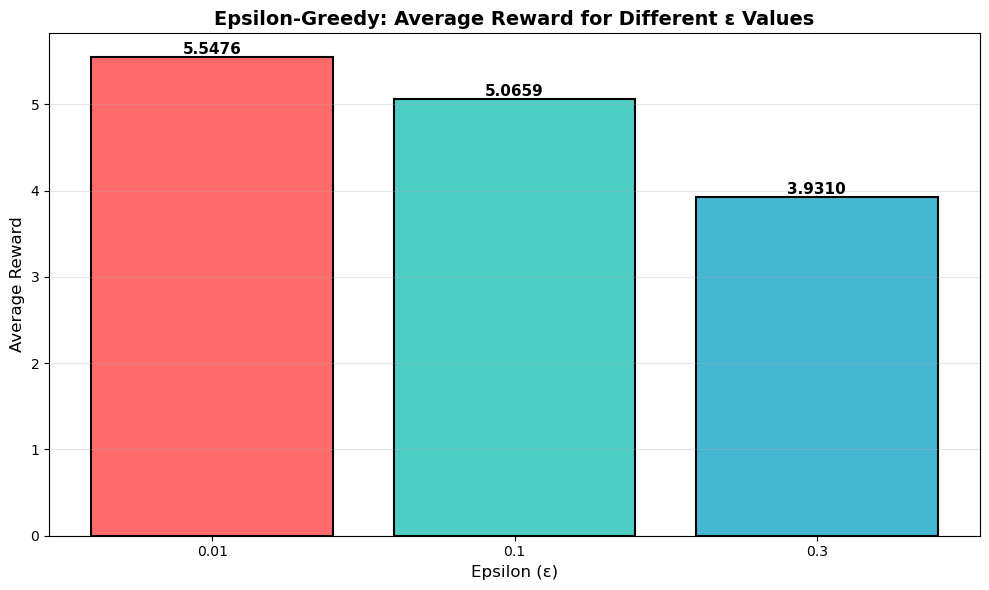


Epsilon-Greedy Results:
  ε = 0.01: Average Reward = 5.5476
  ε = 0.10: Average Reward = 5.0659
  ε = 0.30: Average Reward = 3.9310


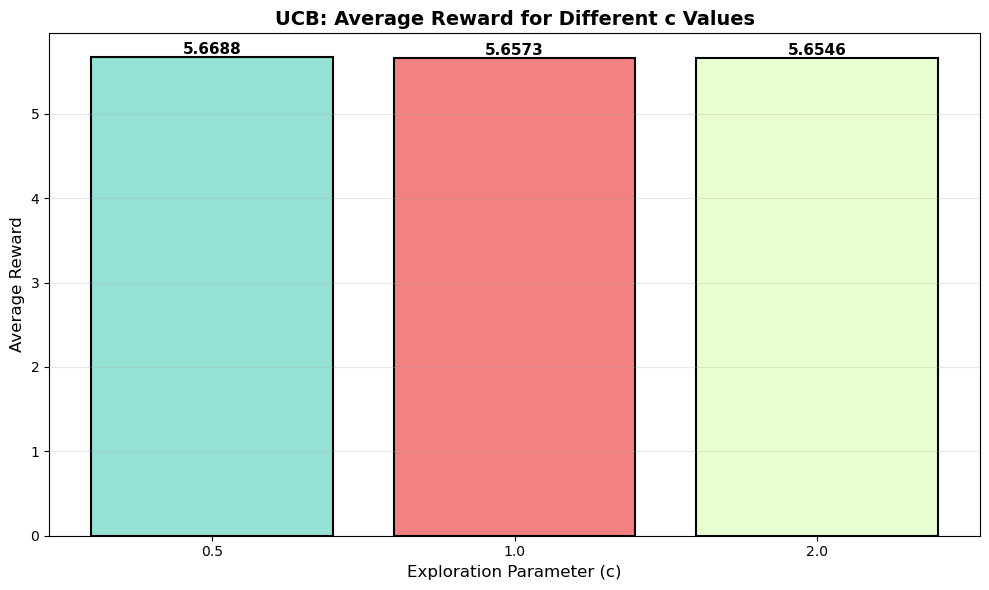


UCB Results:
  c =  0.5: Average Reward = 5.6688
  c =  1.0: Average Reward = 5.6573
  c =  2.0: Average Reward = 5.6546


In [18]:
# ============================================================
# PART 9: HYPERPARAMETER COMPARISON
# ============================================================

# Compare Epsilon-Greedy with different epsilon values
print("="*60)
print("HYPERPARAMETER COMPARISON")
print("="*60)

# Epsilon-Greedy comparison
epsilon_results = {}
for eps, agent in eg_agents.items():
    avg_reward = np.mean(agent.reward_history)
    epsilon_results[eps] = avg_reward

plt.figure(figsize=(10, 6))
epsilons = list(epsilon_results.keys())
rewards = list(epsilon_results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar([str(e) for e in epsilons], rewards, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Epsilon (ε)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('Epsilon-Greedy: Average Reward for Different ε Values', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEpsilon-Greedy Results:")
for eps, reward in epsilon_results.items():
    print(f"  ε = {eps:4.2f}: Average Reward = {reward:.4f}")

# UCB comparison
ucb_results = {}
for c, agent in ucb_agents.items():
    avg_reward = np.mean(agent.reward_history)
    ucb_results[c] = avg_reward

plt.figure(figsize=(10, 6))
c_values_list = list(ucb_results.keys())
rewards = list(ucb_results.values())
colors = ['#95E1D3', '#F38181', '#EAFFD0']

bars = plt.bar([str(c) for c in c_values_list], rewards, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Exploration Parameter (c)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('UCB: Average Reward for Different c Values', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nUCB Results:")
for c, reward in ucb_results.items():
    print(f"  c = {c:4.1f}: Average Reward = {reward:.4f}")

OVERALL ALGORITHM COMPARISON

Best Configuration for Each Algorithm:
  Epsilon-Greedy (ε=0.01)       : 5.5476
  UCB (c=0.5)                   : 5.6688
  SoftMax (τ=1.0)               : 5.5249


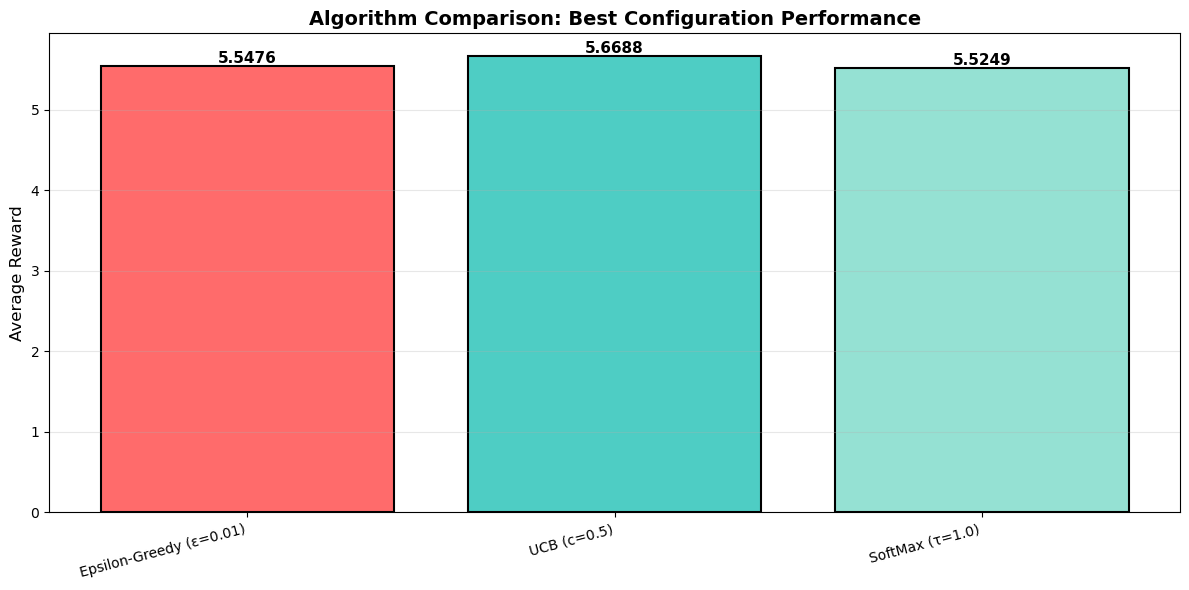


🏆 Best Overall Algorithm: UCB (c=0.5)
   Average Reward: 5.6688


In [19]:
# ============================================================
# PART 10: OVERALL ALGORITHM COMPARISON
# ============================================================

print("="*60)
print("OVERALL ALGORITHM COMPARISON")
print("="*60)

# Get best performance from each algorithm
best_eg = max(eg_agents.items(), key=lambda x: np.mean(x[1].reward_history))
best_ucb = max(ucb_agents.items(), key=lambda x: np.mean(x[1].reward_history))
best_softmax = (tau, softmax_agent)

comparison_results = {
    f'Epsilon-Greedy (ε={best_eg[0]})': np.mean(best_eg[1].reward_history),
    f'UCB (c={best_ucb[0]})': np.mean(best_ucb[1].reward_history),
    f'SoftMax (τ={best_softmax[0]})': np.mean(best_softmax[1].reward_history)
}

print("\nBest Configuration for Each Algorithm:")
for algo, reward in comparison_results.items():
    print(f"  {algo:30s}: {reward:.4f}")

# Visualize
plt.figure(figsize=(12, 6))
algorithms = list(comparison_results.keys())
rewards = list(comparison_results.values())
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

bars = plt.bar(algorithms, rewards, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Average Reward', fontsize=12)
plt.title('Algorithm Comparison: Best Configuration Performance', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Determine best overall algorithm
best_algorithm = max(comparison_results, key=comparison_results.get)
best_reward = comparison_results[best_algorithm]

print(f"\n🏆 Best Overall Algorithm: {best_algorithm}")
print(f"   Average Reward: {best_reward:.4f}")

PER-CONTEXT REWARD ANALYSIS

1. Epsilon-Greedy (Best Configuration)
   user_1: 7.4712
   user_2: 4.3811
   user_3: 4.8012

2. UCB (Best Configuration)
   user_1: 7.7065
   user_2: 4.4656
   user_3: 4.8436

3. SoftMax
   user_1: 7.6875
   user_2: 4.1965
   user_3: 4.7612


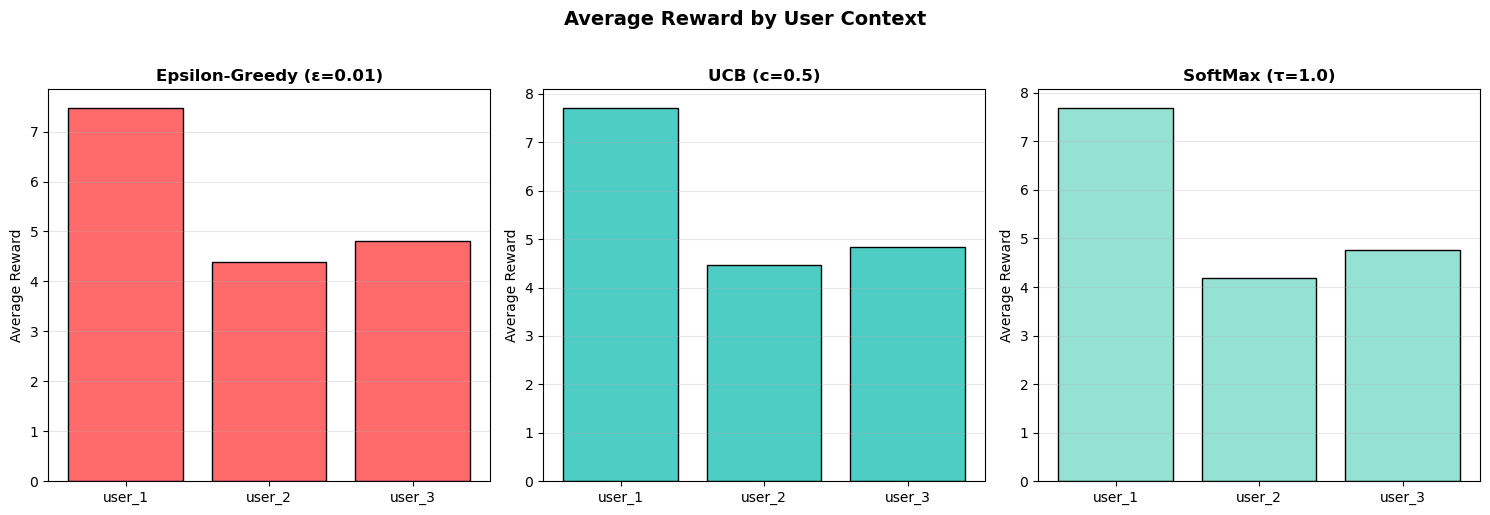

In [20]:
# ============================================================
# PART 11: PER-CONTEXT REWARD ANALYSIS
# ============================================================

def analyze_context_performance(agent, user_categories):
    """Analyze performance for each user context"""
    context_rewards = {user: [] for user in user_categories}
    
    for arm, reward in zip(agent.arm_history, agent.reward_history):
        # Determine which context this arm belongs to
        if arm in [0, 1, 2, 3]:
            context_rewards['user_1'].append(reward)
        elif arm in [4, 5, 6, 7]:
            context_rewards['user_2'].append(reward)
        elif arm in [8, 9, 10, 11]:
            context_rewards['user_3'].append(reward)
    
    # Calculate average rewards
    avg_context_rewards = {user: np.mean(rewards) if rewards else 0 
                           for user, rewards in context_rewards.items()}
    
    return avg_context_rewards

print("="*60)
print("PER-CONTEXT REWARD ANALYSIS")
print("="*60)

# Analyze for the best agent from each algorithm
print("\n1. Epsilon-Greedy (Best Configuration)")
eg_context_rewards = analyze_context_performance(best_eg[1], user_categories)
for user, reward in eg_context_rewards.items():
    print(f"   {user}: {reward:.4f}")

print("\n2. UCB (Best Configuration)")
ucb_context_rewards = analyze_context_performance(best_ucb[1], user_categories)
for user, reward in ucb_context_rewards.items():
    print(f"   {user}: {reward:.4f}")

print("\n3. SoftMax")
softmax_context_rewards = analyze_context_performance(softmax_agent, user_categories)
for user, reward in softmax_context_rewards.items():
    print(f"   {user}: {reward:.4f}")

# Visualize per-context performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

contexts = list(eg_context_rewards.keys())

# Epsilon-Greedy
rewards = list(eg_context_rewards.values())
axes[0].bar(contexts, rewards, color='#FF6B6B', edgecolor='black')
axes[0].set_title(f'Epsilon-Greedy (ε={best_eg[0]})', fontweight='bold')
axes[0].set_ylabel('Average Reward')
axes[0].grid(axis='y', alpha=0.3)

# UCB
rewards = list(ucb_context_rewards.values())
axes[1].bar(contexts, rewards, color='#4ECDC4', edgecolor='black')
axes[1].set_title(f'UCB (c={best_ucb[0]})', fontweight='bold')
axes[1].set_ylabel('Average Reward')
axes[1].grid(axis='y', alpha=0.3)

# SoftMax
rewards = list(softmax_context_rewards.values())
axes[2].bar(contexts, rewards, color='#95E1D3', edgecolor='black')
axes[2].set_title(f'SoftMax (τ={tau})', fontweight='bold')
axes[2].set_ylabel('Average Reward')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Average Reward by User Context', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Recommendation Engine (20 Points)

In [21]:
# ============================================================
# PART 12: RECOMMENDATION ENGINE
# ============================================================

class NewsRecommendationEngine:
    """End-to-end news recommendation system using CMAB"""
    
    def __init__(self, user_classifier, bandit_policy, news_df, scaler, label_encoders):
        """
        Args:
            user_classifier: Trained user classification model
            bandit_policy: Trained bandit agent (EpsilonGreedy, UCB, or SoftMax)
            news_df: News articles DataFrame
            scaler: Fitted StandardScaler
            label_encoders: Dictionary of fitted LabelEncoders
        """
        self.user_classifier = user_classifier
        self.bandit_policy = bandit_policy
        self.news_df = news_df
        self.scaler = scaler
        self.label_encoders = label_encoders
        
        # Map news categories to standardized format
        self.category_map = {
            'entertainment': 'Entertainment',
            'education': 'Education',
            'tech': 'Tech',
            'crime': 'Crime'
        }
    
    def preprocess_user(self, user_features):
        """Preprocess user features for classification"""
        # Handle missing values
        for col in user_features.columns:
            if user_features[col].isnull().any():
                if user_features[col].dtype in ['int64', 'float64']:
                    user_features[col].fillna(user_features[col].median(), inplace=True)
                else:
                    user_features[col].fillna(user_features[col].mode()[0], inplace=True)
        
        # Encode categorical features
        for col, le in self.label_encoders.items():
            if col in user_features.columns:
                user_features[col] = user_features[col].astype(str)
                user_features[col] = user_features[col].apply(
                    lambda x: x if x in le.classes_ else le.classes_[0]
                )
                user_features[col] = le.transform(user_features[col])
        
        # Convert boolean to int
        if 'subscriber' in user_features.columns:
            user_features['subscriber'] = user_features['subscriber'].astype(int)
        
        # Scale features
        user_features_scaled = self.scaler.transform(user_features)
        
        return user_features_scaled
    
    def classify_user(self, user_features):
        """Step 1: Classify user into user category"""
        user_features_processed = self.preprocess_user(user_features.copy())
        user_category = self.user_classifier.predict(user_features_processed)[0]
        return user_category
    
    def select_news_category(self, user_category):
        """Step 2: Select optimal news category using bandit policy"""
        context_arms = get_context_arms(user_category)
        
        # Get best arm from learned policy
        arm_rewards = {arm: self.bandit_policy.arm_avg_rewards.get(arm, 0) 
                      for arm in context_arms}
        best_arm = max(arm_rewards, key=arm_rewards.get)
        
        # Map arm to news category
        arm_offset = best_arm % 4
        news_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
        selected_category = news_categories[arm_offset]
        
        return selected_category, best_arm
    
    def recommend_article(self, user_features):
        """
        Step 3: Complete recommendation pipeline
        
        Args:
            user_features: DataFrame with single user's features
        
        Returns:
            dict: Recommended article details
        """
        # Step 1: Classify user
        user_category = self.classify_user(user_features)
        
        # Step 2: Select news category
        news_category, arm = self.select_news_category(user_category)
        
        # Step 3: Sample random article from selected category
        # Normalize category names for matching
        news_df_copy = self.news_df.copy()
        news_df_copy['category_normalized'] = news_df_copy['category'].str.lower().str.capitalize()
        
        category_articles = news_df_copy[news_df_copy['category_normalized'] == news_category]
        
        if len(category_articles) == 0:
            # Fallback: try case-insensitive match
            category_articles = news_df_copy[
                news_df_copy['category'].str.lower() == news_category.lower()
            ]
        
        if len(category_articles) > 0:
            recommended_article = category_articles.sample(n=1).iloc[0]
        else:
            # Final fallback: random article
            recommended_article = self.news_df.sample(n=1).iloc[0]
        
        # Return recommendation details
        return {
            'user_category': user_category,
            'recommended_news_category': news_category,
            'arm_selected': arm,
            'article': recommended_article.to_dict()
        }

print("="*60)
print("RECOMMENDATION ENGINE")
print("="*60)

# Use the best performing bandit agent
# Assuming best_model is the Random Forest from earlier
recommendation_engine = NewsRecommendationEngine(
    user_classifier=best_model,  # Your best classifier from Part 1
    bandit_policy=best_eg[1],     # Best epsilon-greedy agent
    news_df=news_articles,
    scaler=scaler,
    label_encoders=label_encoders
)

print("\n✓ Recommendation Engine initialized")
print(f"  User Classifier: {type(best_model).__name__}")
print(f"  Bandit Policy: Epsilon-Greedy (ε={best_eg[0]})")

# Test with a few users from test set
print("\n" + "="*60)
print("TESTING RECOMMENDATIONS")
print("="*60)

for i in range(3):
    print(f"\n--- Test User {i+1} ---")
    
    # Get a test user
    test_user = test_users_final.iloc[[i]].drop('user_id', axis=1)
    
    # Get recommendation
    recommendation = recommendation_engine.recommend_article(test_user)
    
    print(f"Predicted User Category: {recommendation['user_category']}")
    print(f"Recommended News Category: {recommendation['recommended_news_category']}")
    print(f"Arm Selected: {recommendation['arm_selected']}")
    print(f"Article Title: {recommendation['article'].get('title', 'N/A')[:80]}...")

print("\n✓ Recommendation engine working successfully!")

RECOMMENDATION ENGINE

✓ Recommendation Engine initialized
  User Classifier: RandomForestClassifier
  Bandit Policy: Epsilon-Greedy (ε=0.01)

TESTING RECOMMENDATIONS

--- Test User 1 ---
Predicted User Category: user_2
Recommended News Category: Education
Arm Selected: 5
Article Title: N/A...

--- Test User 2 ---
Predicted User Category: user_1
Recommended News Category: Entertainment
Arm Selected: 0
Article Title: N/A...

--- Test User 3 ---
Predicted User Category: user_1
Recommended News Category: Entertainment
Arm Selected: 0
Article Title: N/A...

✓ Recommendation engine working successfully!


## 5. Evaluation & Reporting (20 Points)

1. Classification Accuracy - Done in Part 1 (90.75% with Random Forest)

2. RL Simulation for T=10,000 - Done in Parts 5, 6, 7

3. Plot Average Reward vs Time - Done in Part 8

4. Plot hyperparameter comparison - Done in Part 9 (ε and C with 3 values each)

### Analysis Plots (Per context reward)

PER-CONTEXT AVERAGE REWARD VS TIME PLOTS

1. Epsilon-Greedy (Best Configuration)


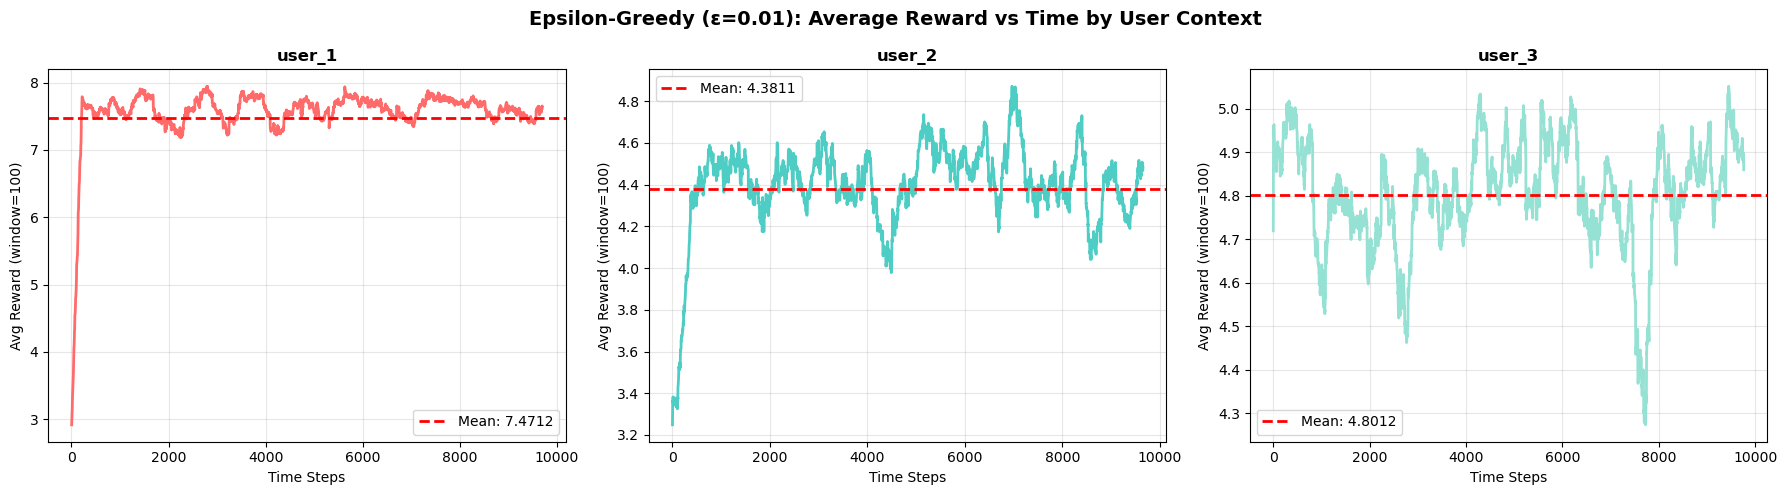


2. UCB (Best Configuration)


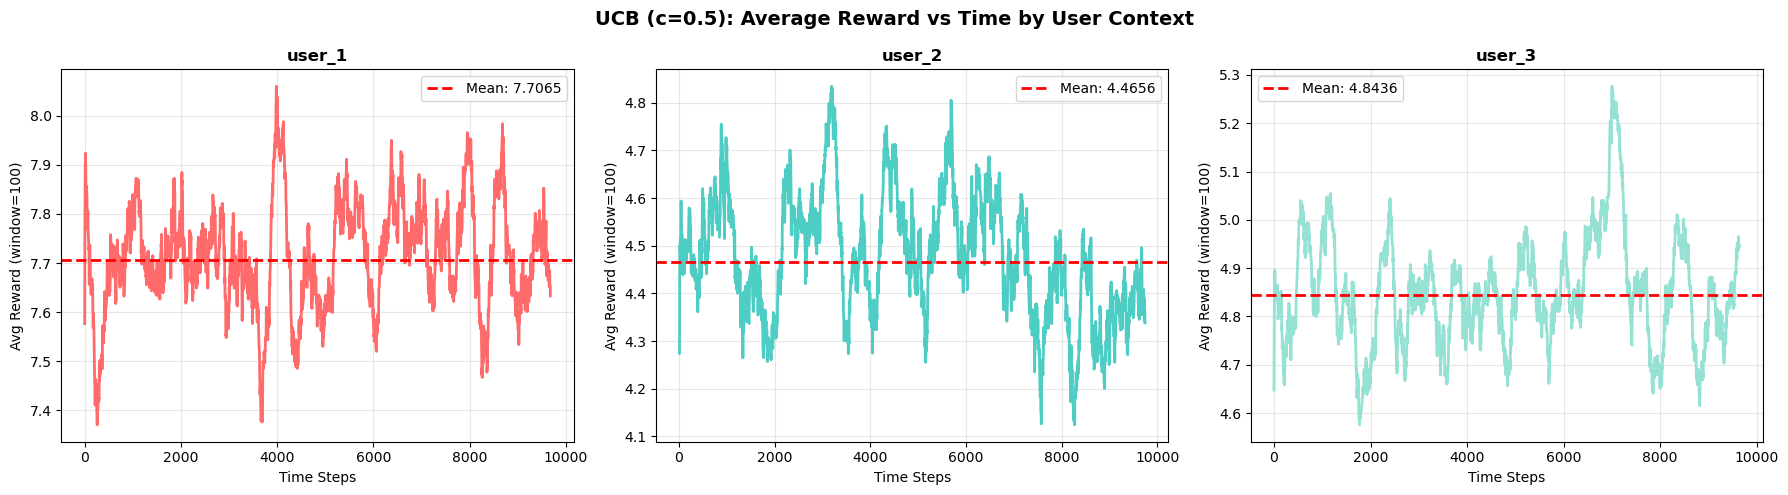


3. SoftMax


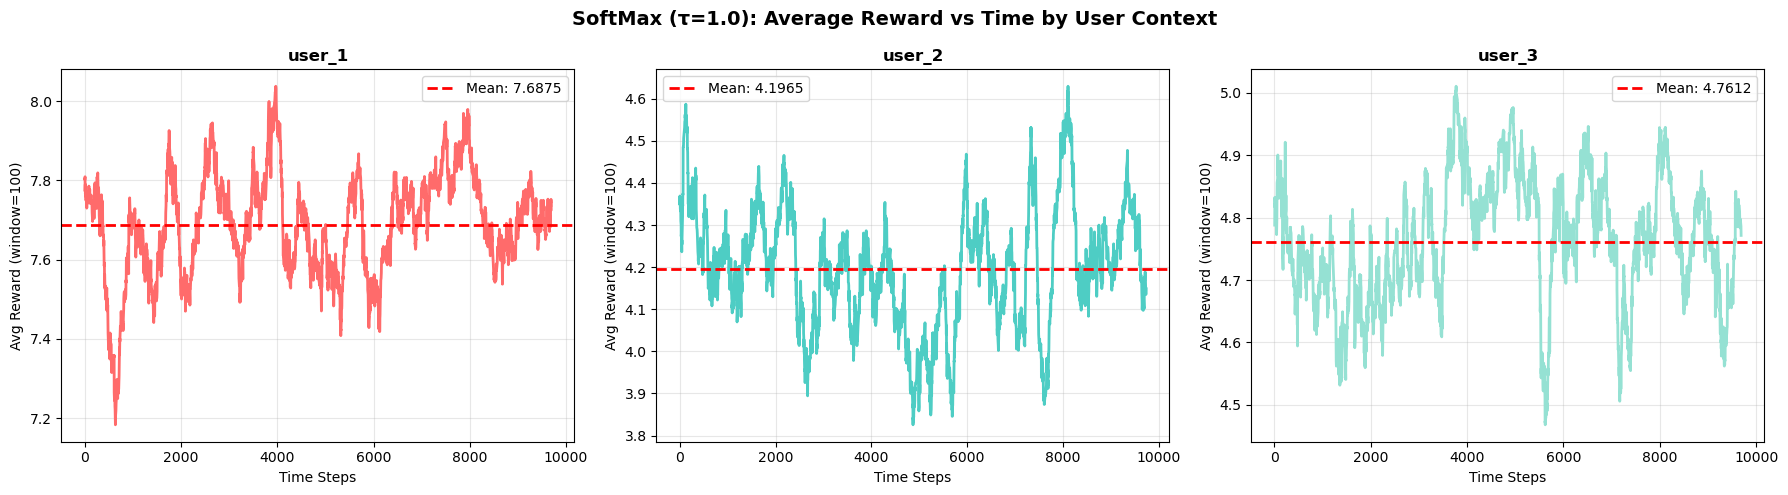

In [24]:
# ============================================================
# PART 13: PER-CONTEXT AVERAGE REWARD VS TIME
# ============================================================

def plot_reward_by_context(agent, agent_name, user_categories, window_size=100):
    """
    Plot average reward over time separated by user context
    """
    # Separate rewards by context
    context_rewards = {user: [] for user in user_categories}
    context_timesteps = {user: [] for user in user_categories}
    
    for t, (arm, reward) in enumerate(zip(agent.arm_history, agent.reward_history)):
        if arm in [0, 1, 2, 3]:
            context_rewards['user_1'].append(reward)
            context_timesteps['user_1'].append(t)
        elif arm in [4, 5, 6, 7]:
            context_rewards['user_2'].append(reward)
            context_timesteps['user_2'].append(t)
        elif arm in [8, 9, 10, 11]:
            context_rewards['user_3'].append(reward)
            context_timesteps['user_3'].append(t)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
    
    for idx, user in enumerate(user_categories):
        rewards = context_rewards[user]
        if len(rewards) > window_size:
            # Calculate moving average
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            timesteps = context_timesteps[user][:len(moving_avg)]
            
            axes[idx].plot(timesteps, moving_avg, color=colors[idx], linewidth=2)
            axes[idx].set_title(f'{user}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Time Steps', fontsize=10)
            axes[idx].set_ylabel(f'Avg Reward (window={window_size})', fontsize=10)
            axes[idx].grid(True, alpha=0.3)
            
            # Add average line
            overall_avg = np.mean(rewards)
            axes[idx].axhline(y=overall_avg, color='red', linestyle='--', 
                            label=f'Mean: {overall_avg:.4f}', linewidth=2)
            axes[idx].legend()
    
    plt.suptitle(f'{agent_name}: Average Reward vs Time by User Context', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("="*60)
print("PER-CONTEXT AVERAGE REWARD VS TIME PLOTS")
print("="*60)

# Plot for best agents
print("\n1. Epsilon-Greedy (Best Configuration)")
plot_reward_by_context(best_eg[1], f'Epsilon-Greedy (ε={best_eg[0]})', user_categories)

print("\n2. UCB (Best Configuration)")
plot_reward_by_context(best_ucb[1], f'UCB (c={best_ucb[0]})', user_categories)

print("\n3. SoftMax")
plot_reward_by_context(softmax_agent, f'SoftMax (τ={tau})', user_categories)